In [4]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets

%matplotlib inline

import warnings
warnings.filterwarnings("ignore")


In [12]:
X, y = datasets.make_blobs(n_samples=100, random_state=4, centers=2, cluster_std=2)
X[:5], y[:5]
# в X хранятся координаты точек ( например (13, 1) )
# в y хранятся принадлежность точки к классу ( В нашем случае 0 или 1 )


(array([[13.78731721,  1.73323541],
        [10.68075246,  3.87600675],
        [ 8.09139034,  0.36429043],
        [10.80129018,  6.34922981],
        [ 8.78819007,  2.53766878]]),
 array([0, 1, 1, 1, 0]))

In [15]:
# Данная функция задает цвет точек ( В нашем случае если класс точки=0, то она голубая, в противном случае зеленая)
def get_class_color(class_label):
    return 'green' if class_label else 'blue'

In [48]:
# X - точки, y - классы точек
# new_points=None - Новые неизвестные точки — для которых угадываем цвет ( в нашем случае их не будет )
# new_prediction=None - Угаданынй цвет для новых точек ( результат алгоритма ) , ( в нашем случае их не будет ) 
# nearest_points=None - Ближайщие соседи точки, которые помогли угадать цвет ( В нашем случае их не будет )
# file_name=None - Название файла чтобы сохранить график ( В нашем случае его не будет )
def plot_points(X, y, new_points=None, new_prediction=None, nearest_points=None, file_name=None):
    plt.figure(figsize=(8,8)) # Создает квадратный график 800x800 or 8x8 дюймов
    
    plt.scatter(X[:,0], X[:,1], c=[get_class_color(y_i) for y_i in y], s=100, edgecolor='black', alpha=0.3)
    # X[:,0] - все координаты точек по оси X ||| X[:,1] - все координаты точек по оси Y ||| c=[get_class_color(y_i) for y_i in y] - определение цвета
    # s=100 - размер точки ( в нашем случае 100px ) ||| edgecolor='black' - цвет рамки ||| alpha=0.3 - прозрачность точки ( в нашем случае 30% )  

    # Если есть нвоые точки то рисуем их черными
    if new_points is not None:
        plt.scatter(new_points[:,0], new_points[:,1], c='black', s=100, edgecolor='black')

    # Перекрашивает новые точки с черного на предсказанный цвет
    if new_prediction is not None:
        plt.scatter(new_points[:,0], new_points[:,1], c=[get_class_color(i) for i in new_prediction], s=100, edgecolor='black')

    # Подсвечивает красным ближайщих соседей точки (для kNN)
    if nearest_points is not None:
        plt.scatter(nearest_points[:,0], nearest_points[:,1], c='red', s=100, edgecolor='black')

    plt.title("Задача классификации. Какой цвет будет у новой пары (x1, x2)?") # заголовок графика над всем рисунком
    plt.xlabel("x1 (функция)") # заголовок оси x
    plt.ylabel("x2 (функция)") # заголовок оси y

    # Если был передан параметр file_name, то сохраняем его в файл
    if file_name:
        plt.savefig(filename) 

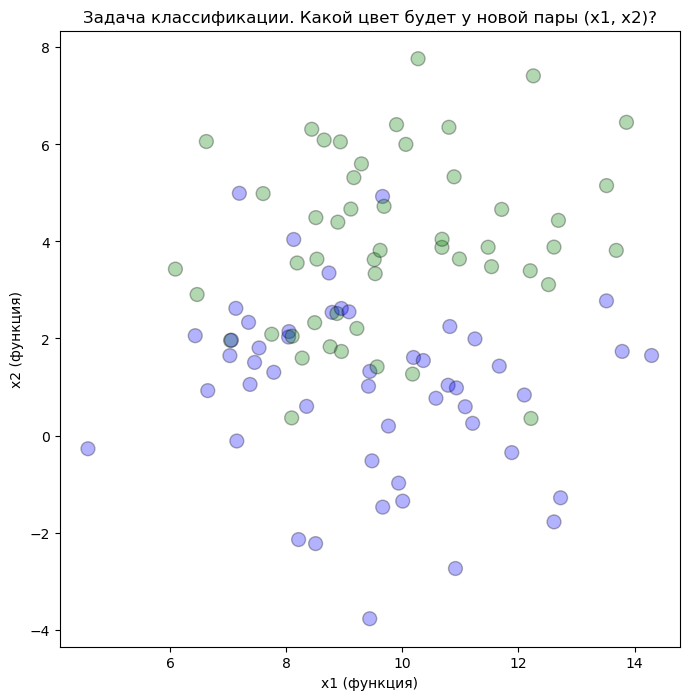

In [49]:
plot_points(X, y)

In [50]:
X_new = np.array([[12,6]])

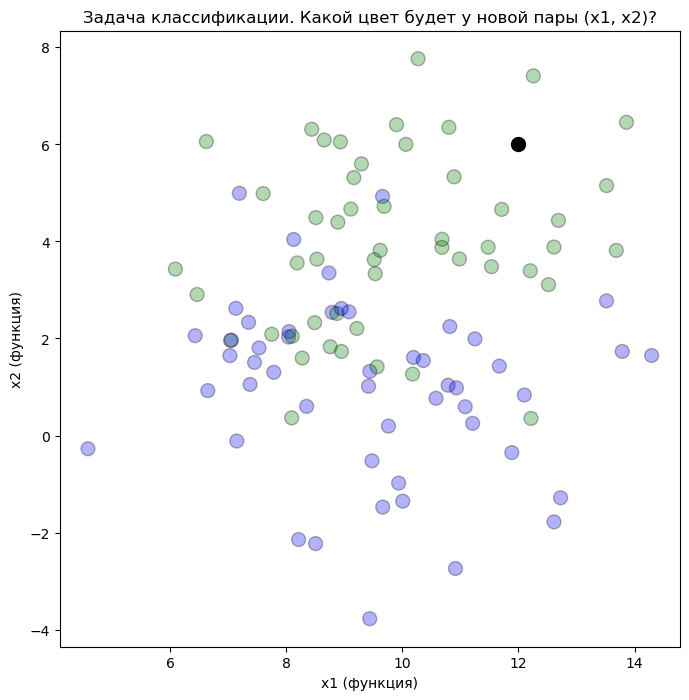

In [51]:
plot_points(X,y, new_points=X_new)

In [56]:
X_new = np.array([[12, 6]]) # Создание новой тестовой точки с координатами вида:
#     [
#       [12,6]
#     ]
X_new 

array([[12,  6]])

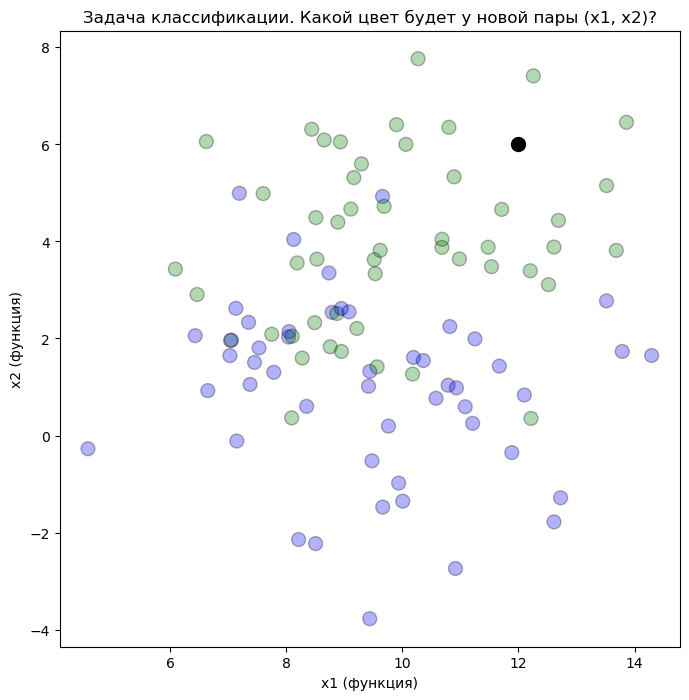

In [57]:
plot_points(X, y, new_points=X_new) # График с новой тестовой точкой


In [68]:
from scipy.spatial.distance import euclidean # Импорт функции евклидового расстояния

# Функция находит индекс ближайщей точки из X к новой точке x_new.
def find_nearest_point_index(x_new, X):
    d_min = euclidean(x_new, X[0]) # инициализирует минимальное расстояние расстоянием до первой точки.
    min_idx = 0 # индекс первой точки
    for idx in range(1,X.shape[0]): # цикл который проходит по всем точкам.
        d = euclidean(x_new, X[idx]) # расстояние от текущей точки до x_new
        if d < d_min: # если текущая точка меньше изначально заданной
            d_min = d # теперь минимальная точка=текущей
            min_idx = idx # индекс минимальной точки теперь равен текущему

    return min_idx # возвращаем индекс минимальной точки
    

min_idx = find_nearest_point_index(X_new[0], X) # находим индекс ближайщей точки через нашу функцию

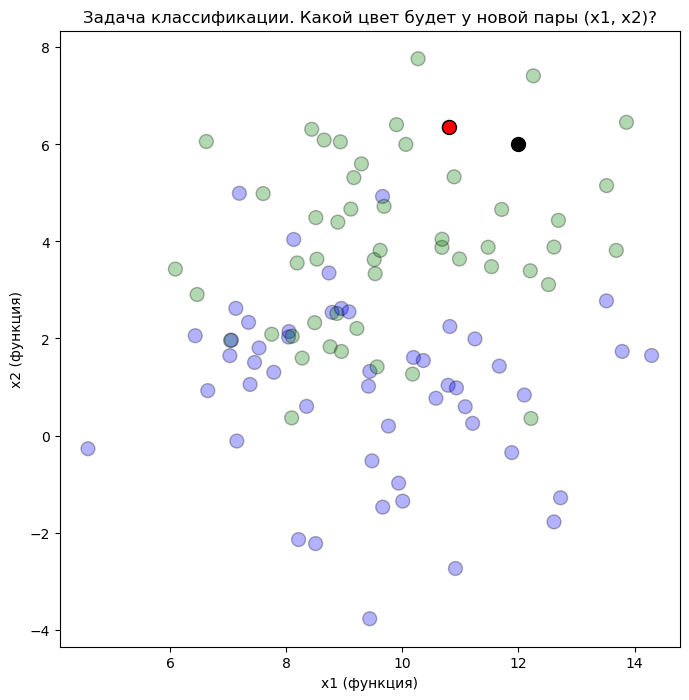

In [69]:
plot_points(X, y, new_points=X_new, nearest_points=X[[min_idx]])  # Рисует крафик с ближайщей точкой

In [74]:
# Функция предсказания пренадлежности точки к какому то классу
def predict_class(x_new, X, y):
    min_idx = find_nearest_point_index(x_new[0], X) # Находит ближайщего соседа
    return y[min_idx] # возвращает класс ближайщего соседа

y_new = predict_class(X_new, X, y) # Делает предсказание класса для новой точки
    

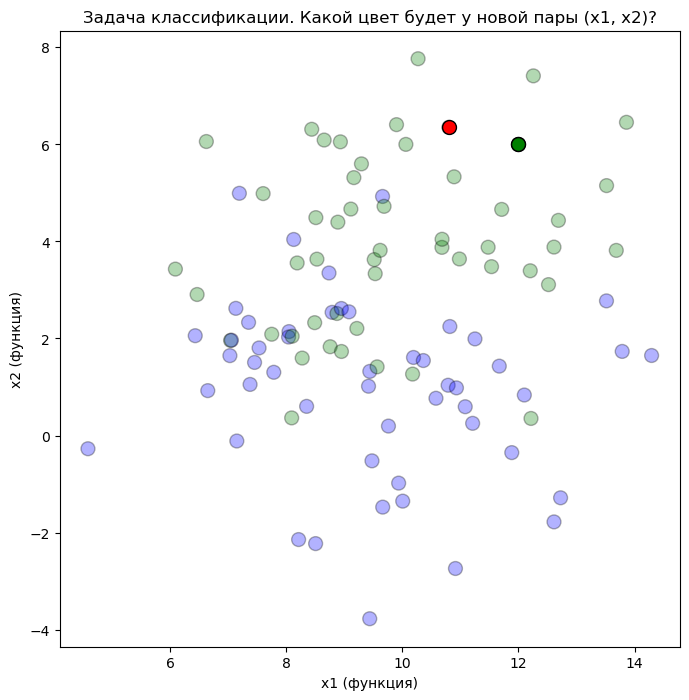

In [80]:
plot_points(X, y, new_points=X_new, new_prediction=[y_new], nearest_points=X[[min_idx]])
# Показывает принадлежность новой точки к определенному классу

In [84]:
X1_new = np.array([[12,-2]]) # создание новой точки
min_idx1 = find_nearest_point_index(X1_new[0], X) # индекс ближайщей точки к нашей 
y_new1 = predict_class(X1_new, X, y) # принадлежность нашей точки к классу

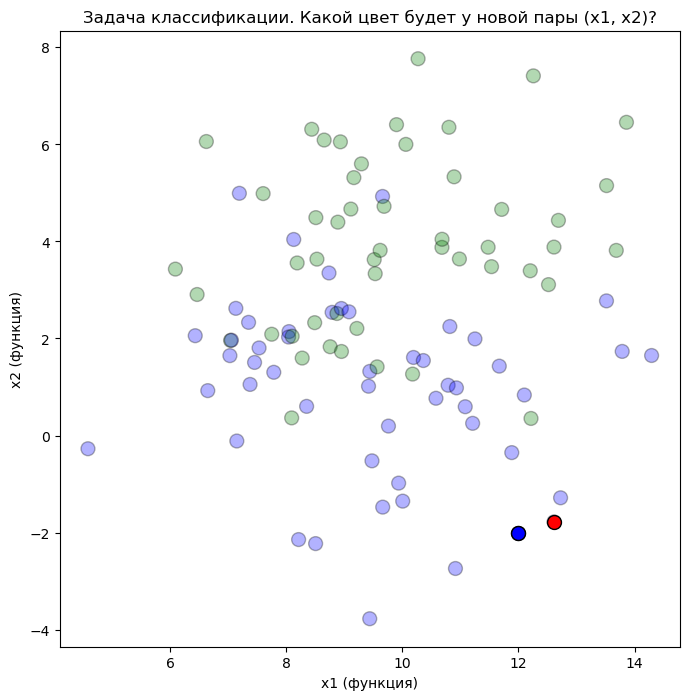

In [88]:
plot_points(X, y, new_points=X1_new, new_prediction=[y_new1], nearest_points=X[[min_idx1]]) # Еще один пример работы всего алгоритма

## Sklearn

In [91]:
from sklearn.neighbors import KNeighborsClassifier # Иморт готового класса kNN

knn = KNeighborsClassifier(n_neighbors=1) # создание объекта kNN классификатора с k=1
knn.fit(X,y) # обучает k-NN модель на данных X и метках y
y_pred = knn.predict(X_new) #  делает предсказание для новой точки X_new=[12,6] с помощью обученной sklearn модели

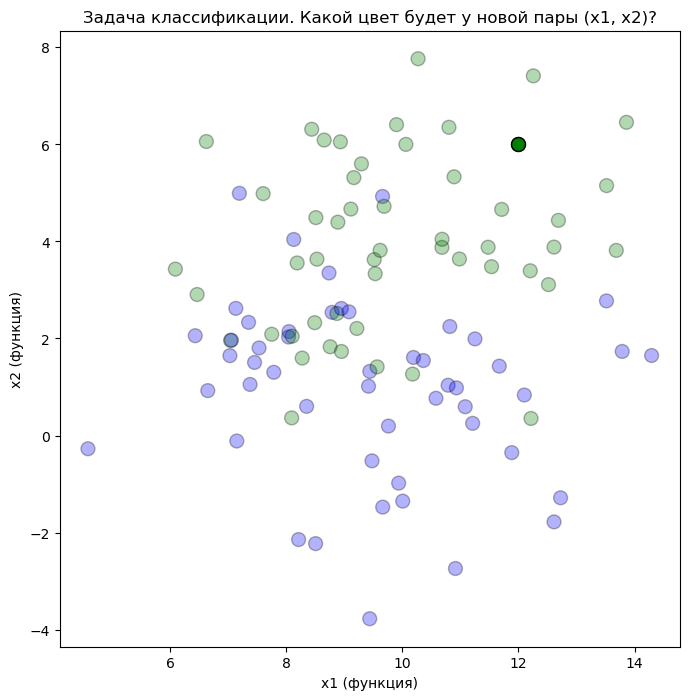

In [93]:
plot_points(X, y, new_points=X_new, new_prediction=[y_pred]) # рисует график на основе обучения 

In [94]:
X_new3 = np.c_[np.random.randint(5,15,10), np.random.randint(-2,8,10)]
# np.c_ - конкатенация массивов numpy
# np.random.randint(нижняя_граница, верхняя_граница, кол-во_чисел) - создает массив из 10 чисел от нижней_границы до верхней_границы

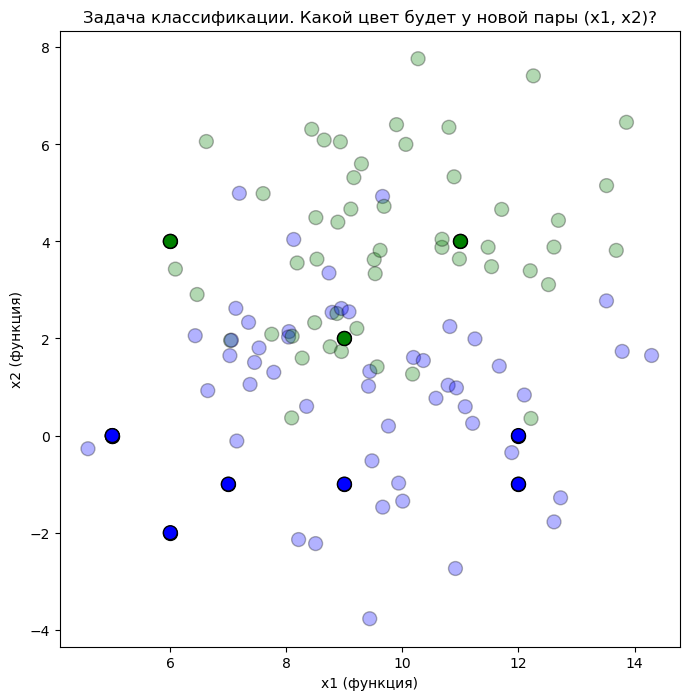

In [96]:
plot_points(X, y, new_points=X_new3, new_prediction=knn.predict(X_new3)) # рисует график на основе новых точек

In [102]:
from scipy.spatial.distance import cdist # импортирует функцию для вычисления матрицы расстояний между двумя наборами точек
from collections import Counter # импортирует класс-счетчик для подсчета частоты элементов

def predict_class(x_new, X, y, k=1): # обновляет функцию для k-NN с любым k
    #  cdist рассчитывает попарные расстояния между объектами
    dist = cdist(x_new, X) #  вычисляет матрицу расстояний от всех новых точек до всех тренировочных

    nearest_y = y[np.argpartition(dist, k, axis=1)[:, :k]] # находит классы k ближайших соседей для каждой новой точки.
    # np.np.argpartition() - argpartition находит отсортированные индексы 

    # Этот код возвращает массив из самых частых значений в каждой строке nearest_y.
    return np.array([Counter(row).most_common(1)[0][0] for row in nearest_y]) 
    # Counter(row) — считает, сколько раз каждый элемент встречается в строке
    # .most_common(1) — берёт самый частый элемент
    # [0][0] — извлекает само значение, а не количество
    # np.array(...) — собирает все такие значения в NumPy-массив.

In [114]:
y_pred = predict_class(X_new3, X, y, k=3) # Это предсказание класса для новых данных X_new по алгоритму k ближайших соседей

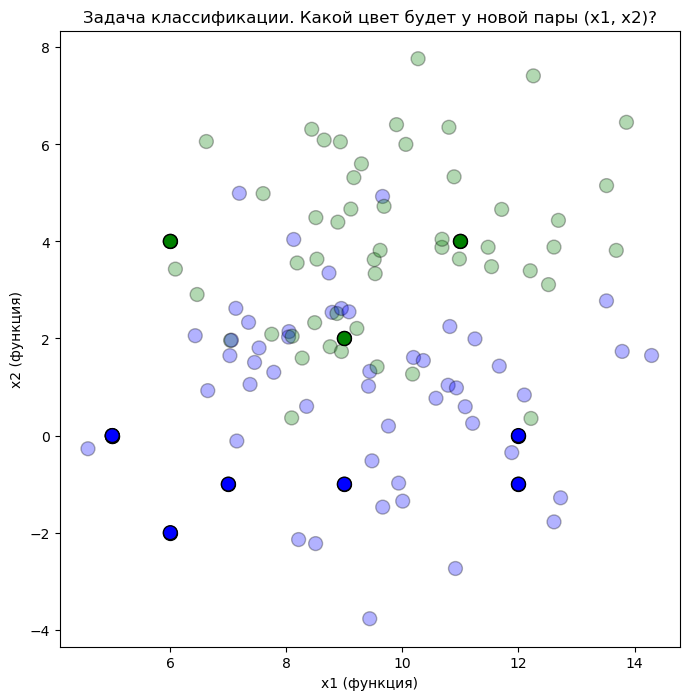

In [115]:
plot_points(X, y, new_points=X_new3, new_prediction=y_pred) # рисует график

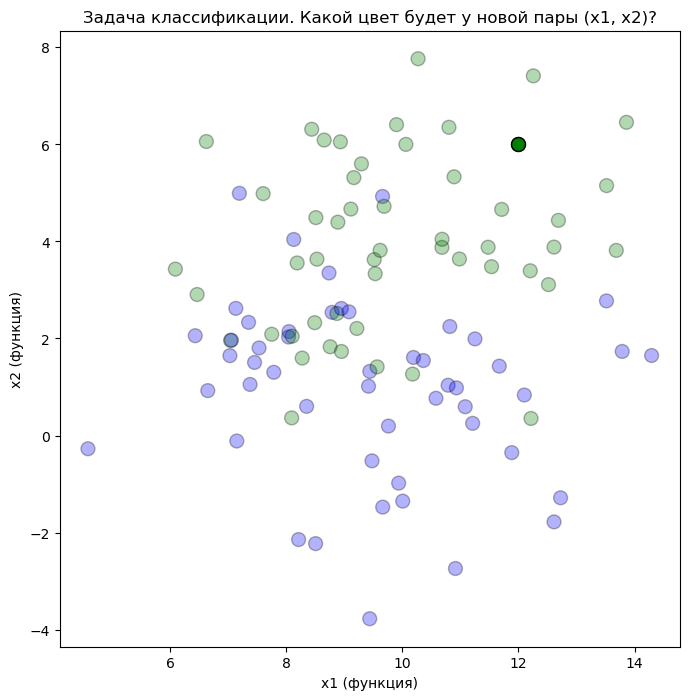

In [120]:
knn = KNeighborsClassifier(n_neighbors=3) #  создаёт модель kNN-классификатора с числом соседей=3
knn.fit(X, y) # обучает модель на данных X и метках y
y_pred = knn.predict(X_new) # получает предсказанные классы для новых данных X_new с помощью уже обученной модели knn
plot_points(X, y, new_points=X_new, new_prediction=y_pred) # строит новый график

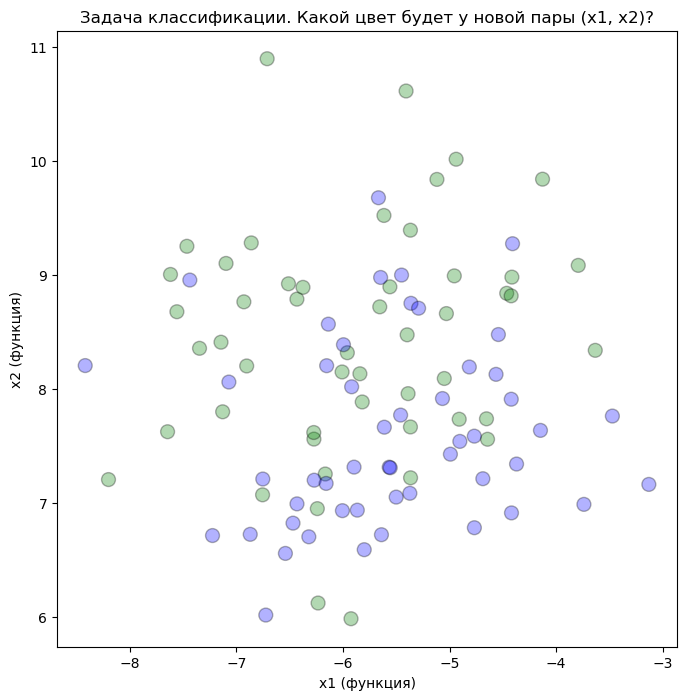

In [122]:
X, y = datasets.make_blobs(n_samples=100, random_state=5, centers=2) # генерирует синтетический набор данных для задач машинного обучения
# make_blobs() - Функция создаёт n случайных точек ( В нашем случае n_samples=100, значит будет создано 100 случайных точек) разделенных на k кластеров
# ( в нашем случае сenters=2, значит 2 кластера)
plot_points(X, y) # рисует график с новыми точками

# Влияние числа соседей k

In [127]:
h = 0.2 # шаг сетки для плавного графика
# Находим границы данных + отступ 0.5 для красивого графика
x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5

xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h)) # создаёт регулярную 2D-сетку координат для визуализации или вычислений
# np.meshgrid() - Принимает два 1D-массива (для осей X и Y) и возвращает две 2D-матрицы xx, yy одинаковой формы.
x_pred = np.c_[xx.ravel(), yy.ravel()] # преобразует 2D-сетку координат в плоский массив точек для предсказания модели.
# xx.ravel(), yy.ravel() -  "сплющивают" 2D-матрицы xx, yy в 1D-массивы (столбцы).